Week2: Dataset Structuring and Validation

In [7]:
import pandas as pd
import os
import re
import datetime
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load Data
listing_filepath = "20260929_w1_csv\\20260929_residential_listing_output.csv"
sold_filepath = "20260929_w1_csv\\20260929_residential_sold_output.csv"

df_listings = pd.read_csv(listings_filepath)
df_sold = pd.read_csv(sold_filepath)

Part 1: Dataset Understanding
•	Identify number of rows and columns
•	Review column data types
•	Identify high-missing columns
•	Separate market analysis fields from metadata fields

In [ ]:
# Shape
print("# of rows | # of columns")
print(df_listings.shape[0],"   |", df_listings.shape[1])
print(df_sold.shape[0],"   |", df_sold.shape[1])

# of rows | # of columns
650190    | 87
493779    | 87


In [ ]:
# Data Types
listing_dtypes = df_listings.dtypes.to_frame('Data Type')
listing_dtypes.insert(0, 'Column Name', listing_dtypes.index)
sold_dtypes = df_sold.dtypes.to_frame('Data Type')
sold_dtypes.insert(0, 'Column Name', sold_dtypes.index)

In [ ]:
# Save Data Types to CSV
listing_dtypes.to_csv('listings_dtypes.csv', index=False)
sold_dtypes.to_csv('sold_dtypes.csv', index=False)

In [ ]:
# Null Value Analysis
listing_null_counts = df_listings.isnull().sum().to_frame('Null Counts')
listing_null_counts.insert(1, 'Null Percentage', round(listing_null_counts['Null Counts'] / df_listings.shape[0] * 100, 2))
listing_null_counts.insert(0, 'Column Name', listing_null_counts.index)
sold_null_counts = df_sold.isnull().sum().to_frame('Null Counts')
sold_null_counts.insert(1, 'Null Percentage', round(sold_null_counts['Null Counts'] / df_sold.shape[0] * 100, 2))
sold_null_counts.insert(0, 'Column Name', sold_null_counts.index)

In [ ]:
# Metadata Analysis
listings_metadataYN = pd.read_csv('listings_metadataYN.csv')
listings_metadata_df = listings_metadataYN.loc[listings_metadataYN.MetadataYN == 'Y']
listings_metadata_cols = listings_metadata_df['Column Name'].tolist()
listings_market_analysis_df = listings_metadataYN.loc[listings_metadataYN.MetadataYN == 'N']
listings_market_analysis_cols = listings_market_analysis_df['Column Name'].tolist()
sold_metadataYN = pd.read_csv('sold_metadataYN.csv')
sold_metadata_df = sold_metadataYN.loc[sold_metadataYN.MetadataYN == 'Y']
sold_market_analysis_df = sold_metadataYN.loc[sold_metadataYN.MetadataYN == 'N']
sold_metadata_cols = sold_metadata_df['Column Name'].tolist()
sold_market_analysis_cols = sold_market_analysis_df['Column Name'].tolist()

In [ ]:
# Select Columns Based on Metadata
listings_metadata = df_listings[listings_metadata_cols]
listings_market_analysis = df_listings[listings_market_analysis_cols]
sold_metadata = df_sold[sold_metadata_cols]
sold_market_analysis = df_sold[sold_market_analysis_cols]

In [ ]:
# Save Datasets to CSV
listings_metadata_dataset = listings_metadata.to_csv('listings_market_analysis_metadata.csv', index=False)
listings_market_analysis_dataset = listings_market_analysis.to_csv('listings_market_analysis.csv', index=False)
sold_metadata_dataset = sold_metadata.to_csv('sold_market_analysis_metadata.csv', index=False)
sold_market_analysis_dataset = sold_market_analysis.to_csv('sold_market_analysis.csv', index=False) 

Part2: Missing Value Analysis
•	Calculate missing counts and percentages per column
•	Flag columns with >90% missing values
•	Decide which columns to drop vs. retain (keep core fields even if partially missing)

In [ ]:
#find null percentages per row
listing_rows = df_listings.shape[0]
sold_rows = df_sold.shape[0]

listing_max_nulls = listing_null_counts[listing_null_counts['Null Percentage'] > 0].sort_values(by='Null Percentage', ascending=False)
sold_max_nulls = sold_null_counts[sold_null_counts['Null Percentage'] > 0].sort_values(by='Null Percentage', ascending=False)

<Axes: xlabel='Null Percentage', ylabel='Count'>

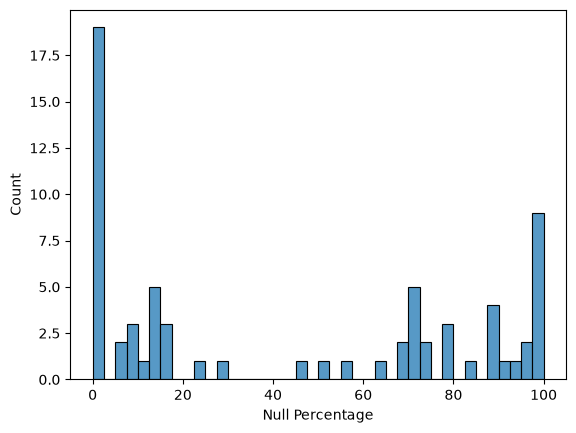

In [ ]:
# Null Value Distribution
data = listing_max_nulls['Null Percentage']
sns.histplot(data=data, bins=40)

In [63]:
# Identify Columns with High Null Percentages
listing_nulls_90Plus = listing_null_counts[listing_null_counts['Null Percentage'] >= 90].sort_values(by='Null Percentage', ascending=False)
sold_nulls_90Plus = sold_null_counts[sold_null_counts['Null Percentage'] >= 90].sort_values(by='Null Percentage', ascending=False)

In [64]:
# Display Columns with High Null Percentages
print('columns with 90%+ nulls in listings:')
print(",".join(listing_nulls_90Plus['Column Name'].tolist()))
print()
print('columns with 90%+ nulls in sold listings:')
print(",".join(sold_nulls_90Plus['Column Name'].tolist()))

columns with 90%+ nulls in listings:
FireplacesTotal,AboveGradeFinishedArea,TaxAnnualAmount,TaxYear,ElementarySchoolDistrict,CoveredSpaces,MiddleOrJuniorSchoolDistrict,BusinessType,BelowGradeFinishedArea,CoBuyerAgentFirstName,BuilderName,LotSizeDimensions,BuildingAreaTotal

columns with 90%+ nulls in sold listings:
FireplacesTotal,TaxAnnualAmount,AboveGradeFinishedArea,TaxYear,CoveredSpaces,MiddleOrJuniorSchoolDistrict,ElementarySchoolDistrict,BusinessType,WaterfrontYN,BelowGradeFinishedArea,BasementYN,BuilderName,LotSizeDimensions,BuildingAreaTotal,CoBuyerAgentFirstName


In [65]:
listing_nulls_80Plus = listing_null_counts[listing_null_counts['Null Percentage'] >= 80].sort_values(by='Null Percentage', ascending=False)
sold_nulls_80Plus = sold_null_counts[sold_null_counts['Null Percentage'] >= 80].sort_values(by='Null Percentage', ascending=False)

In [67]:
# Drop Columns with High Null Percentages (80%+)
listing_data_w2_deliverable = df_listings.drop(columns=listing_nulls_80Plus['Column Name'].tolist())
sold_data_w2_deliverable = df_sold.drop(columns=sold_nulls_80Plus['Column Name'].tolist())


In [68]:
# Save the cleaned data to CSV files
listing_data_w2_deliverable.to_csv('listing_data_w2_deliverable.csv', index=False)
sold_data_w2_deliverable.to_csv('sold_data_w2_deliverable.csv', index=False)